# Policy Visualization

Exploratory plots for RL culling policies with MAC/MIP/disease state variables.

In [1]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
STEP = 60
Q_TABLE_PATH = Path("outputs/UB.pkl")
TRACK_START_MACS = (4, 7, 10)
MAX_OPEN_MAC = 19

MODEL_STEM = Q_TABLE_PATH.stem
FIGURES_DIR = Path("outputs") / "figures" / MODEL_STEM
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLOR_MAP = {
    "open": "#1f77b4",
    "preg": "#f28e2b",
    "cull": "#111111",
    "healthy": "#2ca02c",
    "sick": "#d62728",
    "tracks": ["#1f77b4", "#f4a2cd", "#f28e2b"]
}
OPEN_COW_COLOR = "#010101"
LINEWIDTH = 2.0
MARKER_SIZE = 5

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black"
})

In [3]:
def stylize_axis(ax, title, xlabel, ylabel, *, zero_line=False):
    """Apply clean styling that matches the legacy white-background figures."""
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if zero_line:
        ax.axhline(0, color="black", linestyle="dashed", linewidth=1)


def track_palette(n):
    base = COLOR_MAP["tracks"]
    if n <= len(base):
        return base[:n]
    repeat = (n // len(base)) + 1
    return (base * repeat)[:n]


def _slugify(*parts):
    tokens = []
    for part in parts:
        text = str(part).strip().lower().replace(" ", "_")
        if text:
            tokens.append(text)
    return "_".join(tokens)


def save_figure(fig, *name_parts):
    """Persist a Matplotlib figure into the policy-specific directory."""
    filename = _slugify(*name_parts) or "figure"
    path = FIGURES_DIR / f"{filename}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {path}")

In [4]:
def load_pickle(filename):
    """Load a pickle file and raise an explicit error if it is missing."""
    path = Path(filename)
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}.")
    print(f"Loaded data from {path}.")
    with path.open("rb") as handle:
        return pickle.load(handle)


def load_q_table(filename):
    """Return a tidy DataFrame plus training metadata from a saved Q-table."""
    q_table, rewards_per_episode, epsilon = load_pickle(filename)
    df = pd.DataFrame.from_dict(q_table, orient="index").reset_index()
    df.columns = ["parity", "mac", "mip", "disease"] + list(df.columns[4:])
    df = df.rename(columns={"Keep": "keep", "Cull": "replace", "Replace": "replace"})
    required_cols = {"keep", "replace"}
    if not required_cols.issubset(df.columns):
        raise KeyError(f"Missing action values: expected {required_cols}, found {set(df.columns)}")
    df["Diff"] = df["keep"] - df["replace"]
    return df, rewards_per_episode, epsilon

In [5]:
def track_cow_from_preg(df, parity, starting_mac, starting_mip=1):
    """Assemble a trajectory for a cow that conceives at a given MAC."""
    mac = starting_mac
    mip = starting_mip
    frames = []
    while mip <= 9 and mac <= df["mac"].max():
        match = df[(df["parity"] == parity) & (df["mac"] == mac) & (df["mip"] == mip)]
        frames.append(match)
        mac += 1
        mip += 1
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=df.columns)


def track_cow_open(df, parity, max_mac=MAX_OPEN_MAC):
    """Return the open-cow trajectory up to the requested MAC."""
    frames = []
    for mac in range(1, max_mac + 1):
        match = df[(df["parity"] == parity) & (df["mac"] == mac) & (df["mip"] == 0)]
        frames.append(match)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=df.columns)

In [6]:
def plot_keep_cull_by_repro(df, parity, step):
    """Plot keep/cull values for open vs pregnant cows at a parity."""
    open_df = df[(df["parity"] == parity) & (df["mip"] == 0)]
    preg_df = df[(df["parity"] == parity) & (df["mip"] != 0)]
    grouped_open = open_df.groupby("mac").mean(numeric_only=True)[["keep", "replace"]].reset_index()
    grouped_preg = preg_df.groupby("mac").mean(numeric_only=True)[["keep", "replace"]].reset_index()
    fig, ax = plt.subplots()
    if not grouped_open.empty:
        ax.plot(
            grouped_open["mac"],
            grouped_open["keep"] / step,
            label="Open keep",
            color=COLOR_MAP["open"],
            marker="o",
            markersize=MARKER_SIZE,
            linewidth=LINEWIDTH,
        )
        ax.plot(
            grouped_open["mac"],
            grouped_open["replace"] / step,
            label="Cull",
            color=COLOR_MAP["cull"],
            marker="o",
            linestyle="--",
            linewidth=LINEWIDTH - 0.4,
        )
    if not grouped_preg.empty:
        ax.plot(
            grouped_preg["mac"],
            grouped_preg["keep"] / step,
            label="Pregnant keep",
            color=COLOR_MAP["preg"],
            marker="o",
            markersize=MARKER_SIZE,
            linewidth=LINEWIDTH,
        )
    stylize_axis(
        ax,
        title=f"Parity {parity}: keep vs cull",
        xlabel="Month after calving (MAC)",
        ylabel="Q-value per month ($)",
    )
    ax.legend(frameon=False)
    ax.set_xticks(sorted(df["mac"].unique()))
    fig.tight_layout()
    save_figure(fig, "keep_cull", f"parity_{parity}")
    plt.show()


def plot_health_mip(df, parity, mip, step):
    """Compare healthy vs sick cows that conceive at a given MIP."""
    healthy = df[(df["parity"] == parity) & (df["mip"] == mip) & (df["disease"] == 0)]
    sick = df[(df["parity"] == parity) & (df["mip"] == mip) & (df["disease"] == 1)]
    fig, (ax_keep, ax_diff) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    if not healthy.empty:
        ax_keep.plot(
            healthy["mac"],
            healthy["keep"] / step,
            label="Keep healthy",
            color=COLOR_MAP["healthy"],
            marker="o",
            markersize=MARKER_SIZE,
            linewidth=LINEWIDTH,
        )
        ax_keep.plot(
            healthy["mac"],
            healthy["replace"] / step,
            label="Cull healthy",
            color=COLOR_MAP["cull"],
            linestyle="--",
            linewidth=LINEWIDTH - 0.4,
        )
        ax_diff.plot(
            healthy["mac"],
            healthy["Diff"],
            label="Healthy",
            color=COLOR_MAP["healthy"],
            marker="o",
            markersize=MARKER_SIZE,
            linewidth=LINEWIDTH,
        )
    if not sick.empty:
        ax_keep.plot(
            sick["mac"],
            sick["keep"] / step,
            label="Keep sick",
            color=COLOR_MAP["sick"],
            marker="o",
            markersize=MARKER_SIZE,
            linewidth=LINEWIDTH,
        )
        ax_keep.plot(
            sick["mac"],
            sick["replace"] / step,
            label="Cull sick",
            color="#7a1d2d",
            linestyle="--",
            linewidth=LINEWIDTH - 0.4,
        )
        ax_diff.plot(
            sick["mac"],
            sick["Diff"],
            label="Sick",
            color=COLOR_MAP["sick"],
            marker="o",
            markersize=MARKER_SIZE,
            linewidth=LINEWIDTH,
        )
    stylize_axis(
        ax_keep,
        title=f"Parity {parity} cows pregnant at MIP {mip}",
        xlabel="",
        ylabel="Q-value per month ($)",
    )
    ax_keep.legend(frameon=False)
    stylize_axis(
        ax_diff,
        title="",
        xlabel="Month after calving (MAC)",
        ylabel="Diff (keep - replace) ($)",
        zero_line=True,
    )
    ax_diff.legend(frameon=False)
    ax_diff.set_xticks(sorted(df["mac"].unique()))
    fig.tight_layout()
    save_figure(fig, "health_mip", f"parity_{parity}", f"mip_{mip}")
    plt.show()


def plot_track_diffs(df_subset, parity, start_macs, health_label, title_suffix, ylim=(-500, 2100)):
    """Plot keep-vs-cull deltas for cows conceiving at different MAC values."""
    fig, ax = plt.subplots(figsize=(9, 4.8))
    colors = track_palette(len(start_macs))
    for color, start_mac in zip(colors, start_macs):
        path = track_cow_from_preg(df_subset, parity, start_mac, starting_mip=1)
        if not path.empty:
            ax.plot(
                path["mac"],
                path["Diff"],
                label=f"Preg at MAC = {start_mac}",
                color=color,
                marker="o",
                markersize=MARKER_SIZE,
                linewidth=LINEWIDTH,
            )
    open_curve = track_cow_open(df_subset, parity, max_mac=MAX_OPEN_MAC)
    if not open_curve.empty:
        ax.plot(
            open_curve["mac"],
            open_curve["Diff"],
            label=f"Parity {parity} open cow",
            color="black",
            linestyle="--",
            linewidth=LINEWIDTH - 0.4,
            marker="o",
            markersize=MARKER_SIZE,
        )
    stylize_axis(
        ax,
        title=f"Value of cows pregnant at different MAC ({title_suffix}, {health_label})",
        xlabel="Month after calving (MAC)",
        ylabel="Q-value difference (keep - replace) ($)",
        zero_line=True,
    )
    ax.set_ylim(ylim)
    ax.legend(frameon=False, loc="upper right")
    ax.set_xticks(sorted(df_subset["mac"].unique()))
    fig.tight_layout()
    save_figure(fig, "track_diffs", f"parity_{parity}", health_label, title_suffix)
    plt.show()

In [7]:
df, rewards_per_episode, epsilon = load_q_table(Q_TABLE_PATH)
print(f"Episodes tracked: {len(rewards_per_episode)}")
print(f"Final epsilon: {epsilon:.4f}")
df.head()

Loaded data from outputs/UB.pkl.
Episodes tracked: 5000000
Final epsilon: 0.0100


,parity,mac,mip,disease,keep,replace,Diff
0,0,0,9,0,2094.633130,76.653119,2017.980011
1,1,1,0,0,1112.463808,75.940502,1036.523307
2,1,1,0,1,58.476779,0.000000,58.476779
3,1,2,0,0,1155.251515,75.932910,1079.318605
4,1,2,0,1,691.270274,-45.732140,737.002414


In [8]:
disease_summary = df.groupby("disease").mean(numeric_only=True)[["keep", "replace", "Diff"]]
disease_summary

,keep,replace,Diff
disease,,,
0,198.809737,431.242182,-232.432445
1,67.532333,76.727337,-9.195004


In [9]:
replacement_rows = df[(df["parity"] == 0) & (df["mac"] == 0) & (df["mip"] == 9)]
display(replacement_rows[["keep", "replace", "Diff"]].head(1))
if not replacement_rows.empty:
    monthly_value = replacement_rows.iloc[0]["keep"] / STEP
    print(f"Replacement heifer expectation per month: ${monthly_value:,.2f}")

,keep,replace,Diff
0,2094.63313,76.653119,2017.980011


Replacement heifer expectation per month: $34.91


Saved figure to outputs/figures/UB/keep_cull_parity_1.png


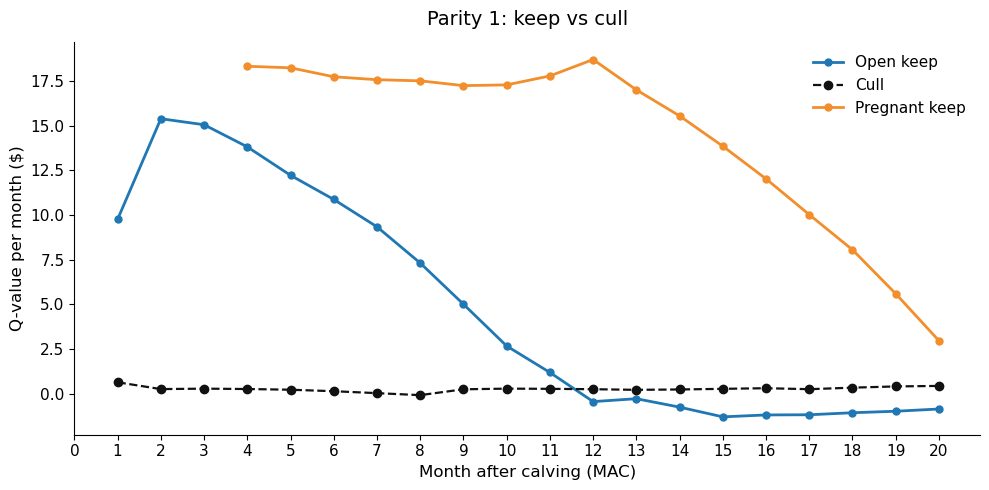

Saved figure to outputs/figures/UB/keep_cull_parity_2.png


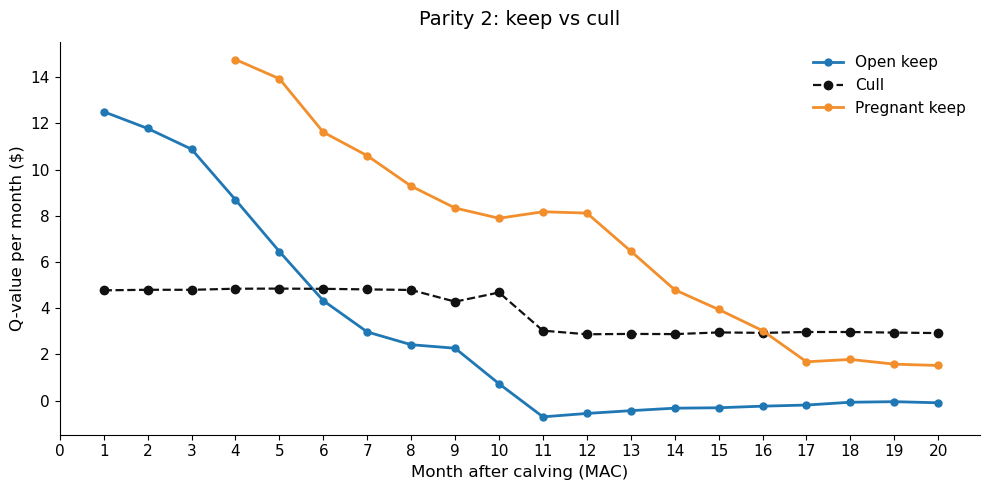

In [10]:
for parity in (1, 2):
    plot_keep_cull_by_repro(df, parity=parity, step=STEP)

Saved figure to outputs/figures/UB/health_mip_parity_1_mip_1.png


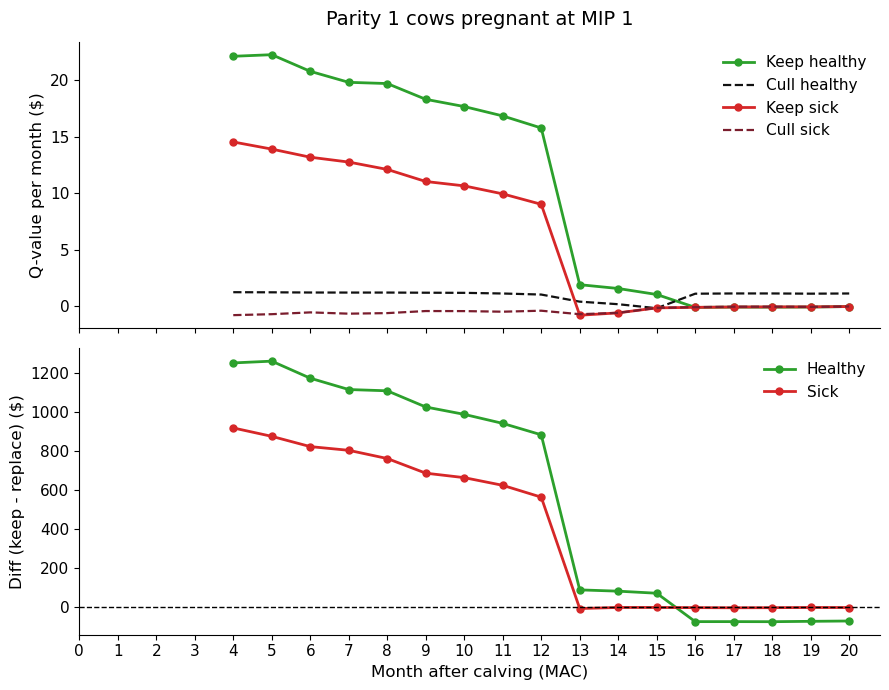

In [11]:
plot_health_mip(df, parity=1, mip=1, step=STEP)

Saved figure to outputs/figures/UB/track_diffs_parity_1_healthy_parity_1.png


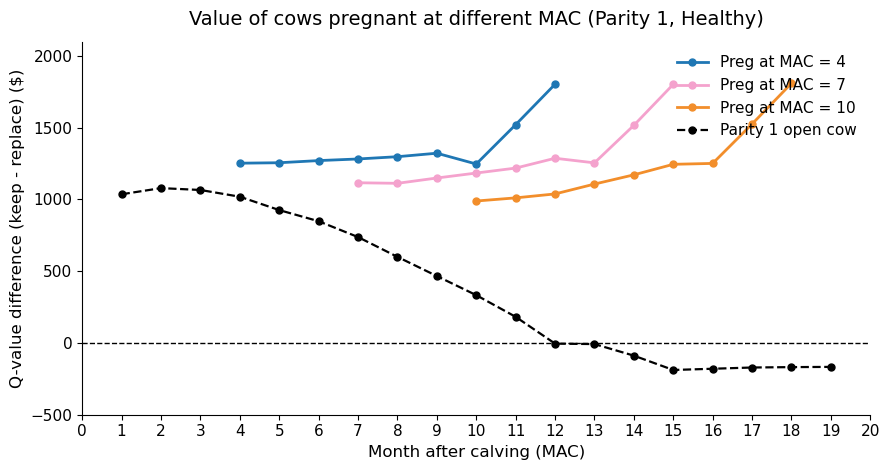

In [12]:
healthy_df = df[df["disease"] == 0]
plot_track_diffs(healthy_df, parity=1, start_macs=TRACK_START_MACS, health_label="Healthy", title_suffix="Parity 1")

Saved figure to outputs/figures/UB/track_diffs_parity_1_sick_parity_1.png


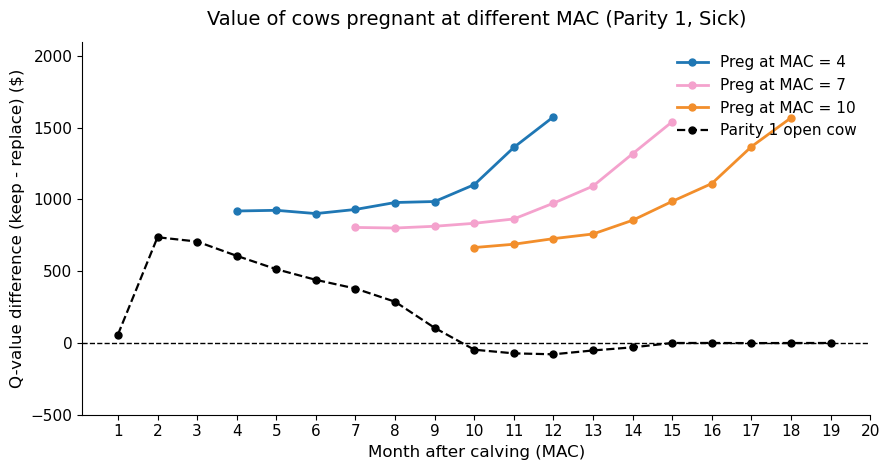

In [13]:
sick_df = df[df["disease"] == 1]
plot_track_diffs(sick_df, parity=1, start_macs=TRACK_START_MACS, health_label="Sick", title_suffix="Parity 1")

Saved figure to outputs/figures/UB/track_diffs_parity_2_healthy_parity_2.png


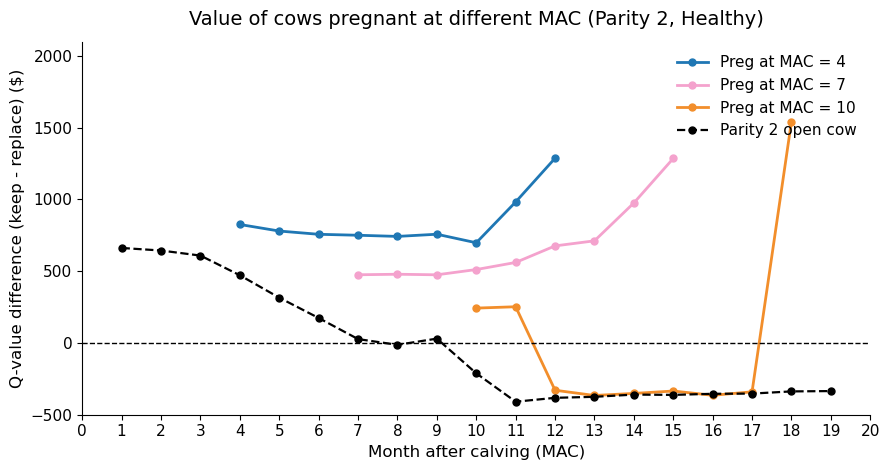

In [14]:
plot_track_diffs(healthy_df, parity=2, start_macs=TRACK_START_MACS, health_label="Healthy", title_suffix="Parity 2")

Saved figure to outputs/figures/UB/track_diffs_parity_2_sick_parity_2.png


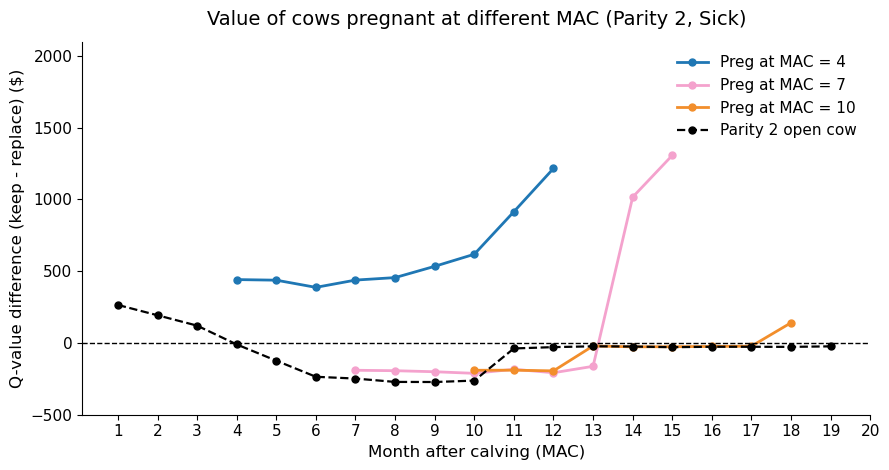

In [15]:
plot_track_diffs(sick_df, parity=2, start_macs=TRACK_START_MACS, health_label="Sick", title_suffix="Parity 2")